# Quotation Win/Loss Prediction — EDA + Logistic Regression

**Goal:** predict whether a construction quotation will be Won (`Success`=1) or Lost (`Success`=0), with an emphasis on explainability (coefficients, odds ratios, SHAP).

**Architecture note (v2):** cleaning and feature engineering are now a proper `fit`/`transform` step (`QuotationCleaner`, Part 2) inside one single `Pipeline`, alongside encoding and the model. `full_pipeline.fit(X_train_raw, y_train)` does everything; `full_pipeline.predict(new_raw_data)` works directly on new quotations in the original Excel format — no manual pre-cleaning step, and no risk of that cleaning drifting out of sync with what the model was actually trained on. Earlier versions of this notebook did cleaning as a separate, unwrapped script before the pipeline — functionally fine for training once, but wrong for reuse: it required copying the cleaning code by hand for any new data, and one step (deciding which wall-type flags are rare) is *stateful* — it has to be learned from training data and frozen, not recomputed on whatever new data comes in.

**This notebook covers:**
1. Load & inspect the data
2. EDA — missing values, target balance, leakage check, distributions, trends
3. `QuotationCleaner` — cleaning & feature engineering as a proper pipeline step
4. Train/test split (time-based)
5. The full pipeline: cleaner → preprocessing → model
6. Baseline Logistic Regression, then tuned
7. Explainability — coefficients, odds ratios, bootstrap significance, SHAP, calibration

> ⚠️ Update `DATA_PATH` in the config cell below.


In [49]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              classification_report, RocCurveDisplay, PrecisionRecallDisplay,
                              brier_score_loss)
from sklearn.calibration import calibration_curve

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


## Configuration

In [48]:
DATA_PATH = r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Quotation Data.xlsx"

RANDOM_STATE = 42
TEST_FRACTION = 0.20
MIN_CATEGORY_COUNT = 15
RARE_WALLTYPE_PCT = 1.0

# WALL_TYPE_COLS / NUMERIC_FEATURES / CATEGORICAL_FEATURES / DROP_COLS / SENTINELS live in
# quotation_pipeline_utils.py now (imported in the next cell) -- single source of truth,
# shared with every other model notebook, instead of copy-pasted into each one.


In [50]:
import sys
sys.path.insert(0, '.')   # ensure the current folder is importable, regardless of how Jupyter was launched
from quotation_pipeline_utils import (
    QuotationCleaner, filter_valid_rows, select_binary_features,
    NUMERIC_FEATURES, CATEGORICAL_FEATURES, WALL_TYPE_COLS, DROP_COLS, SENTINELS
)
print('Imported QuotationCleaner from quotation_pipeline_utils.py')


Imported QuotationCleaner from quotation_pipeline_utils.py


In [51]:
# Load data
df_raw = pd.read_excel(DATA_PATH, sheet_name='Data')
print('Shape:', df_raw.shape)
#df_raw.head(9)

Shape: (4620, 55)


## Part 3 — Train/Test Split

Time-based, as established in Part 1: sort by date, hold out the most recent 20%. The only change from earlier versions — `filter_valid_rows` runs on the *raw* dataframe (dropping the ~3.9% of rows with no parseable quote date, needed to sort chronologically at all), and everything downstream of that is raw, uncleaned data. `QuotationCleaner` doesn't run until it's `.fit()` as the first step of the pipeline itself.

In [52]:
df_valid = filter_valid_rows(df_raw)
df_valid['_Date_parsed'] = pd.to_datetime(df_valid['Date'], errors='coerce')
df_sorted = df_valid.sort_values('_Date_parsed').reset_index(drop=True)

TARGET = 'Success'
X = df_sorted.drop(columns=[TARGET, '_Date_parsed'])   # raw columns -- QuotationCleaner handles the rest
y = df_sorted[TARGET]

split_idx = int(len(df_sorted) * (1 - TEST_FRACTION))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train:', len(X_train), '| Test:', len(X_test), '| Split date:', df_sorted['_Date_parsed'].iloc[split_idx].date())
print('Train win rate:', round(y_train.mean(),3), '| Test win rate:', round(y_test.mean(),3))


Dropped 179 rows with missing/invalid quote Date (3.9%)
Train: 3552 | Test: 889 | Split date: 2024-03-26
Train win rate: 0.279 | Test win rate: 0.169


### Why not a random split? (quantifying the difference, as in Part 1)

In [53]:
quick_pipe = Pipeline([
    ('cleaner', QuotationCleaner(rare_walltype_pct=RARE_WALLTYPE_PCT)),
    ('preprocessor', ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), NUMERIC_FEATURES),
        ('bin', 'passthrough', select_binary_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist', min_frequency=MIN_CATEGORY_COUNT, sparse_output=False), CATEGORICAL_FEATURES)
    ])),
    ('model', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))
])

quick_pipe.fit(X_train, y_train)
auc_time = roc_auc_score(y_test, quick_pipe.predict_proba(X_test)[:, 1])

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X, y, test_size=TEST_FRACTION, stratify=y, random_state=RANDOM_STATE)
quick_pipe.fit(Xr_tr, yr_tr)
auc_random = roc_auc_score(yr_te, quick_pipe.predict_proba(Xr_te)[:, 1])

print(f'ROC-AUC, time-based split: {auc_time:.3f}   <- honest, used everywhere below')
print(f'ROC-AUC, random split    : {auc_random:.3f}   <- inflated, for illustration only')


ROC-AUC, time-based split: 0.622   <- honest, used everywhere below
ROC-AUC, random split    : 0.775   <- inflated, for illustration only


## Part 4 — The Full Pipeline

One `Pipeline`, three steps: `QuotationCleaner` (raw columns → engineered features) → `ColumnTransformer` (impute/scale numeric, pass through binary flags, one-hot the categoricals) → `LogisticRegression`. `fit()` on raw training data does everything; `predict()`/`predict_proba()` on any new raw quotation does too.

In [54]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), NUMERIC_FEATURES),
    ('bin', 'passthrough', select_binary_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist',
                           min_frequency=MIN_CATEGORY_COUNT, sparse_output=False), CATEGORICAL_FEATURES)
])

log_reg = Pipeline([
    ('cleaner', QuotationCleaner(rare_walltype_pct=RARE_WALLTYPE_PCT)),
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))
])


## Part 5 — Baseline Logistic Regression

In [64]:
log_reg.fit(X_train, y_train)
n_common_walls = len(log_reg.named_steps['cleaner'].common_walls_)
print(f'Fitted. {n_common_walls} wall-type flags kept individually (>= {RARE_WALLTYPE_PCT}% prevalence in training data),',
      f'{len(WALL_TYPE_COLS) - n_common_walls} collapsed into Rare_WorkType.')
print('Encoded feature count:', len(log_reg.named_steps['preprocessor'].get_feature_names_out()))


Fitted. 13 wall-type flags kept individually (>= 1.0% prevalence in training data), 24 collapsed into Rare_WorkType.
Encoded feature count: 130


If this wall-type count differs from an earlier version of this notebook, that's the leakage fix described in Part 2 working as intended — it's now computed from training data only, not the full dataset.

In [66]:
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print('=== Test set performance (time-based holdout) ===')
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}   (naive 'always Loss' baseline: {1-y_test.mean():.3f})")
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall   : {recall_score(y_test, y_pred):.3f}')
print(f'F1       : {f1_score(y_test, y_pred):.3f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}')
print(f'PR-AUC   : {average_precision_score(y_test, y_proba):.3f}   (baseline = positive rate = {y_test.mean():.3f})')
print()
print(classification_report(y_test, y_pred, target_names=['Loss', 'Won']))


=== Test set performance (time-based holdout) ===
Accuracy : 0.823   (naive 'always Loss' baseline: 0.831)
Precision: 0.400
Recall   : 0.093
F1       : 0.151
ROC-AUC  : 0.622
PR-AUC   : 0.272   (baseline = positive rate = 0.169)

              precision    recall  f1-score   support

        Loss       0.84      0.97      0.90       739
         Won       0.40      0.09      0.15       150

    accuracy                           0.82       889
   macro avg       0.62      0.53      0.53       889
weighted avg       0.77      0.82      0.77       889



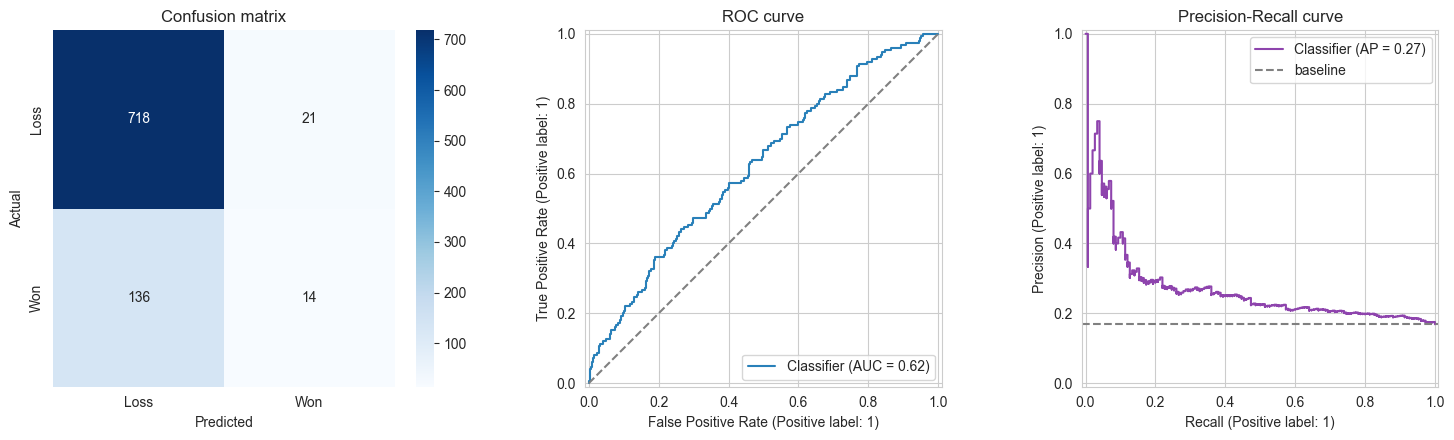

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Loss','Won'], yticklabels=['Loss','Won'], ax=axes[0])
axes[0].set_title('Confusion matrix'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color='#2980b9')
axes[1].plot([0,1],[0,1],'--',color='gray'); axes[1].set_title('ROC curve')
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2], color='#8e44ad')
axes[2].axhline(y_test.mean(), linestyle='--', color='gray', label='baseline'); axes[2].set_title('Precision-Recall curve'); axes[2].legend()
plt.tight_layout(); plt.show()


**Honest read:** ROC-AUC around ~0.6 is modest — well above random but far from strong, and expected for model 1 of 7 evaluated against a deliberately harder-than-random time-based split (Part 3) on data with the temporal drift found in Part 1. Not a finished result, a baseline to compare the rest against.

## Part 6 — Hyperparameter Tuning

`C`, `penalty` (L1/L2/elasticnet via `solver='saga'`, the one solver supporting all three), and `class_weight` (`None` vs `'balanced'`) via `TimeSeriesSplit`. `class_weight` mostly shifts the classification *threshold*, so don't be surprised if `None` wins under a ranking metric like `average_precision` even though the data is imbalanced — that's a real result, not a bug, and it's exactly why Part 7 doesn't stop at coefficients.

In [68]:
param_grid = {
    'model__solver': ['saga'],
    'model__penalty': ['l1', 'l2', 'elasticnet'],
    'model__C': [0.05, 0.1, 1.0, 3.0],
    'model__class_weight': [None, 'balanced'],
    'model__l1_ratio': [0.5],
}
tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(log_reg, param_grid, scoring='average_precision', cv=tscv, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_log_reg = grid_search.best_estimator_
print('Best params:', grid_search.best_params_)
print('Best CV PR-AUC:', round(grid_search.best_score_, 3))


Best params: {'model__C': 1.0, 'model__class_weight': None, 'model__l1_ratio': 0.5, 'model__penalty': 'l1', 'model__solver': 'saga'}
Best CV PR-AUC: 0.519


In [71]:
y_pred_best = best_log_reg.predict(X_test)
y_proba_best = best_log_reg.predict_proba(X_test)[:, 1]

print('=== Tuned model vs Part 5 baseline ===')
for name, fn in [('ROC-AUC', roc_auc_score), ('PR-AUC', average_precision_score)]:
    print(f'{name:<10} baseline={fn(y_test, y_proba):.3f}  tuned={fn(y_test, y_proba_best):.3f}')
for name, fn in [('Precision', precision_score), ('Recall', recall_score), ('F1', f1_score)]:
    print(f'{name:<10} baseline={fn(y_test, y_pred):.3f}  tuned={fn(y_test, y_pred_best):.3f}')


=== Tuned model vs Part 5 baseline ===
ROC-AUC    baseline=0.622  tuned=0.625
PR-AUC     baseline=0.272  tuned=0.271
Precision  baseline=0.400  tuned=0.500
Recall     baseline=0.093  tuned=0.007
F1         baseline=0.151  tuned=0.013


## Part 7 — Explainability

Same three layers as before: coefficients & odds ratios, bootstrap significance, SHAP. One mechanical change from the pipeline restructure — getting the *encoded* matrix (needed for bootstrap/SHAP) now means running `X_train` through the cleaner and preprocessor steps but not the model, via `pipeline[:-1].transform(...)` (a Pipeline slice), rather than calling `.named_steps['preprocessor'].transform()` directly on already-clean data as before.

**On statsmodels:** still intentionally not used — with ~135 one-hot columns, unregularized MLE risks quasi-separation and unstable estimates. Bootstrap answers the same question directly on the model actually being used.

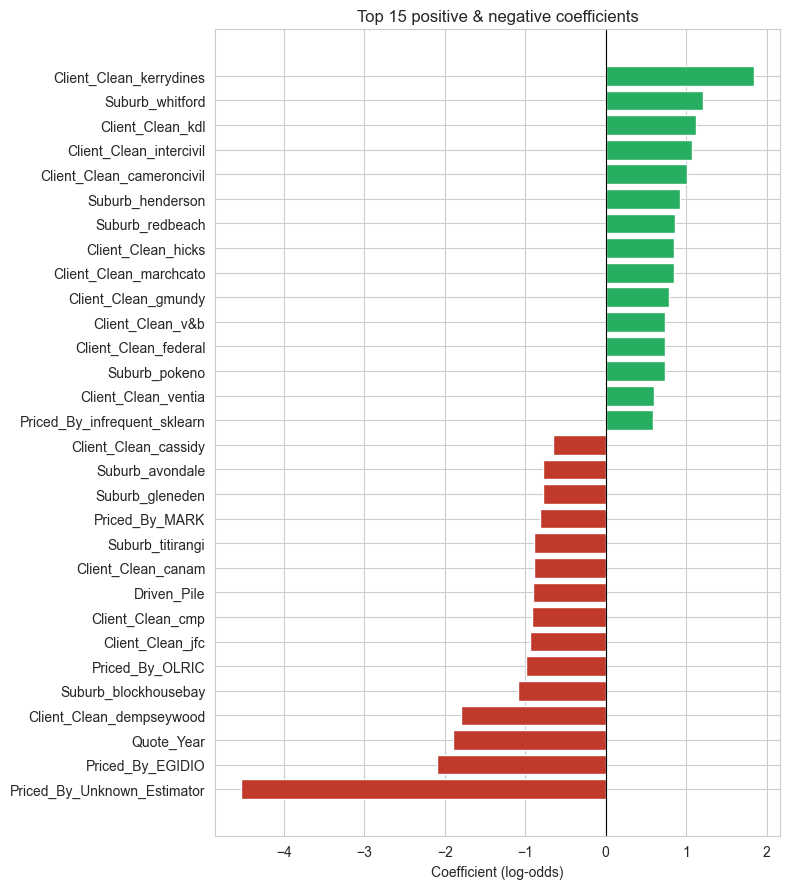

,feature,coefficient,odds_ratio
51,Client_Clean_kerrydines,1.846943,6.340405
118,Suburb_whitford,1.211243,3.357657
50,Client_Clean_kdl,1.128076,3.089708
47,Client_Clean_intercivil,1.072428,2.922465
23,Client_Clean_cameroncivil,1.008482,2.741436
84,Suburb_henderson,0.918465,2.505441
106,Suburb_redbeach,0.865245,2.375587
45,Client_Clean_hicks,0.852902,2.346447
54,Client_Clean_marchcato,0.852629,2.345805
39,Client_Clean_gmundy,0.790256,2.203961


In [69]:
feature_names = best_log_reg.named_steps['preprocessor'].get_feature_names_out()
clean_names = [f.replace('num__','').replace('bin__','').replace('cat__','') for f in feature_names]
coefs = best_log_reg.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'feature': clean_names, 'coefficient': coefs})
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df = coef_df.sort_values('coefficient', ascending=False)

top_n = 15
plot_df = pd.concat([coef_df.head(top_n), coef_df.tail(top_n)]).drop_duplicates()
fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#27ae60' if c > 0 else '#c0392b' for c in plot_df['coefficient']]
ax.barh(plot_df['feature'], plot_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)'); ax.set_title(f'Top {top_n} positive & negative coefficients')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
coef_df.head(15)


In [ ]:
N_BOOT = 300
X_train_enc = best_log_reg[:-1].transform(X_train)   # cleaner + preprocessor, not the model -- pipeline slicing
best_C = grid_search.best_params_['model__C']
y_train_arr = y_train.values
n = X_train_enc.shape[0]

rng = np.random.RandomState(RANDOM_STATE)
boot_coefs = np.zeros((N_BOOT, X_train_enc.shape[1]))
for i in range(N_BOOT):
    idx = rng.randint(0, n, n)
    Xb, yb = X_train_enc[idx], y_train_arr[idx]
    m = LogisticRegression(C=best_C, class_weight='balanced', max_iter=2000)
    m.fit(Xb, yb)
    boot_coefs[i] = m.coef_[0]

ci_low = np.percentile(boot_coefs, 2.5, axis=0)
ci_high = np.percentile(boot_coefs, 97.5, axis=0)
sig = np.sign(ci_low) == np.sign(ci_high)
boot_df = pd.DataFrame({
    'feature': clean_names, 
    'coef_mean': boot_coefs.mean(axis=0), 
    'ci_2.5%': ci_low, 
    'ci_97.5%': ci_high, 
    'significant_95pct_CI': sig})

print(f'{sig.sum()} / {len(sig)} features have a 95% bootstrap CI that excludes zero.')
boot_df[boot_df['significant_95pct_CI']].sort_values('coef_mean', ascending=False)


31 / 130 features have a 95% bootstrap CI that excludes zero.


,feature,coef_mean,ci_2.5%,ci_97.5%,significant_95pct_CI
51,Client_Clean_kerrydines,1.634581,0.688881,2.370406,True
50,Client_Clean_kdl,1.164956,0.401049,1.877227,True
23,Client_Clean_cameroncivil,1.146872,0.264420,1.903672,True
118,Suburb_whitford,1.083204,0.190654,1.925473,True
129,Priced_By_infrequent_sklearn,0.949419,0.198880,1.776552,True
39,Client_Clean_gmundy,0.918583,0.066257,1.778052,True
84,Suburb_henderson,0.876927,0.162776,1.584201,True
45,Client_Clean_hicks,0.873444,0.406370,1.328521,True
54,Client_Clean_marchcato,0.869198,0.306565,1.451694,True
122,Priced_By_GARY,0.634325,0.109946,1.168343,True


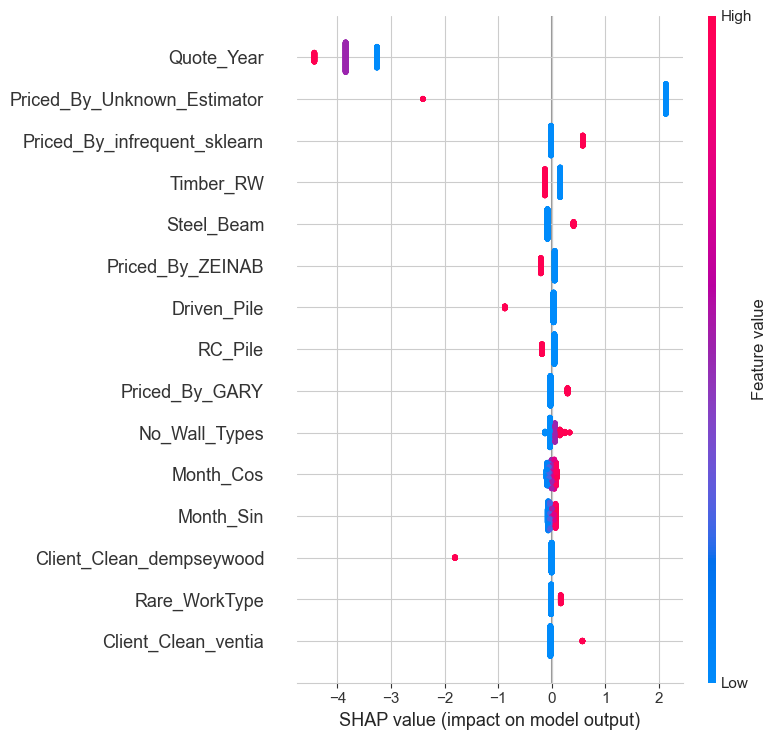

In [72]:
import shap

X_test_enc = best_log_reg[:-1].transform(X_test)
lr_model = best_log_reg.named_steps['model']
mean_train_enc = X_train_enc.mean(axis=0)
base_value = lr_model.intercept_[0] + np.dot(lr_model.coef_[0], mean_train_enc)
shap_manual = (X_test_enc - mean_train_enc) * lr_model.coef_[0]

explainer = shap.LinearExplainer(lr_model, X_train_enc, feature_names=clean_names)
shap_values = explainer(X_test_enc)
shap.summary_plot(shap_values, X_test_enc, feature_names=clean_names, max_display=15, show=True)


Example: test row 270, actual = Won, predicted probability = 0.546


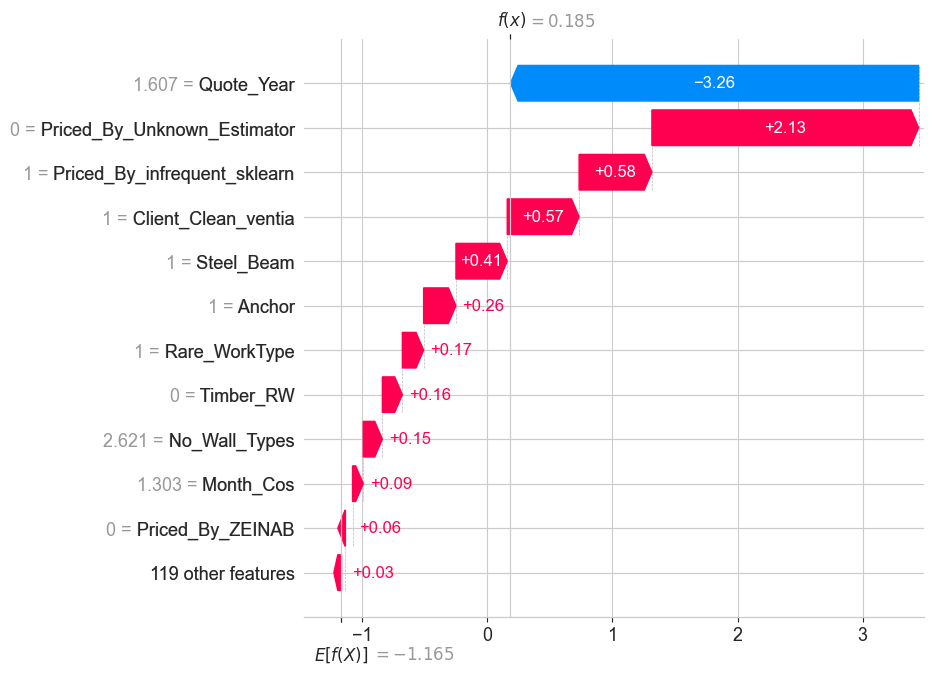

In [73]:
test_idx_won = np.where(y_test.values == 1)[0]
example_idx = test_idx_won[np.argmax(y_proba_best[test_idx_won])]
print(f'Example: test row {example_idx}, actual = Won, predicted probability = {y_proba_best[example_idx]:.3f}')
shap.plots.waterfall(shap_values[example_idx], max_display=12)


## Model Calibration

Same rationale as before: `class_weight`/ranking-metric tuning distorts raw probabilities away from true frequencies. Fit on the first 80% of the training period, calibrate on the last 20%, evaluate on the untouched test set — using `FrozenEstimator` (sklearn ≥1.6) so calibration only rescales the already-fitted model's output rather than refitting on partial data (the `cv=TimeSeriesSplit(...)` shortcut silently does the latter and can hurt ranking — confirmed by direct comparison in the very first version of this notebook).

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

calib_split = int(split_idx * 0.8)
X_cfit, y_cfit = X.iloc[:calib_split], y.iloc[:calib_split]
X_calib, y_calib = X.iloc[calib_split:split_idx], y.iloc[calib_split:split_idx]

calib_base = clone(best_log_reg)
calib_base.fit(X_cfit, y_cfit)
proba_uncalibrated = calib_base.predict_proba(X_test)[:, 1]

calibrated_log_reg = CalibratedClassifierCV(FrozenEstimator(calib_base), method='sigmoid')
calibrated_log_reg.fit(X_calib, y_calib)
proba_calibrated = calibrated_log_reg.predict_proba(X_test)[:, 1]

print(f'Brier, uncalibrated: {brier_score_loss(y_test, proba_uncalibrated):.4f}')
print(f'Brier, calibrated  : {brier_score_loss(y_test, proba_calibrated):.4f}')
print(f'ROC-AUC, uncalibrated: {roc_auc_score(y_test, proba_uncalibrated):.3f}  | calibrated: {roc_auc_score(y_test, proba_calibrated):.3f}')


In [ ]:
frac_pos_u, mean_pred_u = calibration_curve(y_test, proba_uncalibrated, n_bins=8, strategy='quantile')
frac_pos_c, mean_pred_c = calibration_curve(y_test, proba_calibrated, n_bins=8, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax.plot(mean_pred_u, frac_pos_u, marker='o', color='#c0392b', label='Uncalibrated')
ax.plot(mean_pred_c, frac_pos_c, marker='o', color='#27ae60', label='Calibrated')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed win rate'); ax.legend()
plt.tight_layout(); plt.show()


## Proof: predicting on new, never-cleaned data — from a genuinely fresh process

Not just calling `.predict()` in the same session (that would have "worked" even with the old bug, since the class was still in memory). This spins up a **separate Python process** — the same situation as opening a new prediction script tomorrow — and confirms it can load the saved file and score a raw row with nothing but `quotation_pipeline_utils.py` sitting next to it.

In [ ]:
import joblib
joblib.dump(best_log_reg, 'logistic_regression_pipeline.joblib')
joblib.dump(calibrated_log_reg, 'logistic_regression_calibrated.joblib')
print('Saved. quotation_pipeline_utils.py must stay in the same folder as this file.')


In [ ]:
import subprocess, textwrap

fresh_process_script = textwrap.dedent("""
    import joblib, pandas as pd
    model = joblib.load('logistic_regression_pipeline.joblib')
    raw = pd.read_excel('DATA_PATH_PLACEHOLDER', sheet_name='Data').sample(3, random_state=7)
    print('LOADED OK in a fresh process:', type(model).__name__)
    print('Predictions:', list(model.predict(raw)))
    print('Win probabilities:', list(model.predict_proba(raw)[:, 1].round(3)))
""").replace('DATA_PATH_PLACEHOLDER', DATA_PATH)

with open('_fresh_process_check.py', 'w') as f:
    f.write(fresh_process_script)

result = subprocess.run(['python', '_fresh_process_check.py'], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print('FAILED:')
    print(result.stderr)


## Summary

- **Architecture fixed**: one `Pipeline` (`cleaner` → `preprocessor` → `model`), fit once on raw data, reusable directly on new raw quotations — verified with an actual fresh-process reload above, not just an in-session `.predict()` call.
- **Second bug caught and fixed in the same pass**: `QuotationCleaner` needed to live in `quotation_pipeline_utils.py`, not inside the notebook — a class pickled from a notebook's namespace can't be resolved by a separate process loading the file later. This shared module is also what every other model notebook now imports from, so the cleaning logic exists in exactly one place.
- **Bonus correctness fix that fell out of the rewrite**: the wall-type "rare" threshold is now computed from training data only, not the full dataset — a small leak in the original version.
- Findings from earlier analysis stand: `Successful`/`number_of_successful` dropped as leakage, time-based split matters a great deal, `Quote_Year`/`Priced_By` dominate explainability, calibration is necessary before trusting raw probabilities.

**Next: Decision Tree**, same shared `quotation_pipeline_utils.py`, same one-`Pipeline` pattern.